In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import cv2
import re

In [2]:
image_jpeg = os.listdir('Images/')
image_cordinate = os.listdir('Labels/')

In [3]:
test_image = mpimg.imread('Images/1.jpeg')

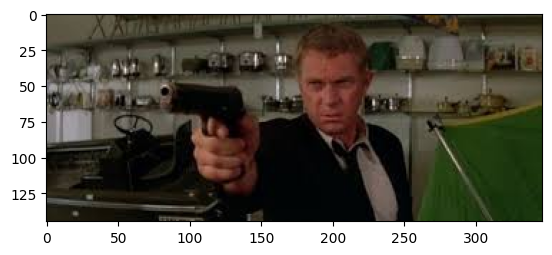

In [4]:
plt.imshow(test_image)

In [5]:
with open('Labels/1.txt','r') as file:
    print(file.read())

1
76 45 146 87



In [6]:
sizes = []
for img_name in os.listdir("Images"):
    img_path = os.path.join("Images", img_name)
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    sizes.append((w, h))

print("Max_size:", min(sizes))
print("Min_size:", max(sizes))

Max_size: (165, 306)
Min_size: (401, 126)


In [7]:
# 416×416

In [8]:
X_train = []
y_train = []

TARGET_SIZE = 416

image_files = sorted(os.listdir("Images"), key=lambda x: int(x.split('.')[0]))

for img_name in image_files:
    
    img_path = os.path.join("Images", img_name)
    txt_name = os.path.splitext(img_name)[0] + ".txt"
    txt_path = os.path.join("Labels", txt_name)

    image = cv2.imread(img_path)
    old_Y, old_X = image.shape[:2]

    with open(txt_path, "r") as f:
        lines = f.readlines()

    num_objects = int(lines[0].strip())

    
    image = cv2.resize(image, (TARGET_SIZE, TARGET_SIZE))
    image = image / 255.0

    scale_x = TARGET_SIZE / old_X
    scale_y = TARGET_SIZE / old_Y

    for line in lines[1:]:
        xmin, ymin, xmax, ymax = map(int, line.strip().split())

        xmin = int(xmin * scale_x)
        ymin = int(ymin * scale_y)
        xmax = int(xmax * scale_x)
        ymax = int(ymax * scale_y)

        X_train.append(image)
        y_train.append([xmin, ymin, xmax, ymax])

X_train = np.array(X_train)
y_train = np.array(y_train)

In [9]:
X_train

array([[[[0.26666667, 0.34117647, 0.36078431],
         [0.26666667, 0.34117647, 0.36078431],
         [0.26666667, 0.34117647, 0.36078431],
         ...,
         [0.18823529, 0.26666667, 0.27058824],
         [0.18823529, 0.26666667, 0.27058824],
         [0.18823529, 0.26666667, 0.27058824]],

        [[0.26666667, 0.34117647, 0.36078431],
         [0.26666667, 0.34117647, 0.36078431],
         [0.26666667, 0.34117647, 0.36078431],
         ...,
         [0.18823529, 0.26666667, 0.27058824],
         [0.18823529, 0.26666667, 0.27058824],
         [0.18823529, 0.26666667, 0.27058824]],

        [[0.26666667, 0.34117647, 0.36078431],
         [0.26666667, 0.34117647, 0.36078431],
         [0.26666667, 0.34117647, 0.36078431],
         ...,
         [0.19215686, 0.27058824, 0.2745098 ],
         [0.19215686, 0.27058824, 0.2745098 ],
         [0.19215686, 0.27058824, 0.2745098 ]],

        ...,

        [[0.06666667, 0.11764706, 0.13333333],
         [0.06666667, 0.11764706, 0.13333333]

In [10]:
y_train

array([[ 91, 129, 175, 249],
       [171,  69, 204, 161],
       [341, 219, 357, 280],
       ...,
       [123, 201, 250, 325],
       [ 58,  96, 210, 353],
       [184, 112, 252, 155]], shape=(428, 4))

In [11]:
X_train.shape

(428, 416, 416, 3)

In [12]:
y_train.shape

(428, 4)

In [13]:
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout, Dense
from keras.optimizers import Adam

In [14]:
model = Sequential()

model.add(Conv2D(filters=64, kernel_size=(5, 5), activation='relu', input_shape=(416, 416, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(units=30, activation='relu'))
model.add(Dense(units=4, activation='linear'))

C:\Users\USER\Desktop\ML jupyter\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(optimizer=Adam(learning_rate=0.001),loss = 'mae')

In [16]:
model.fit(X_train, y_train, validation_split=0.2, epochs=30,batch_size = 32)

Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - loss: 161.2798 - val_loss: 97.4668
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - loss: 89.9541 - val_loss: 87.0036
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - loss: 84.4146 - val_loss: 77.2150
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - loss: 79.1930 - val_loss: 77.3361
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - loss: 75.8643 - val_loss: 71.0615
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - loss: 72.9235 - val_loss: 69.3567
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - loss: 72.0573 - val_loss: 67.5342
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - loss: 73.6216 - val_loss: 70.8581
Epoch 9/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - loss: 71.6976 - val_loss: 69.3076
Epoch 10/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - loss: 71.6463 - val_loss: 68.9745
Epoch 11/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - loss: 73.8076 - val_loss: 76.9627
Epoch 12/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step 

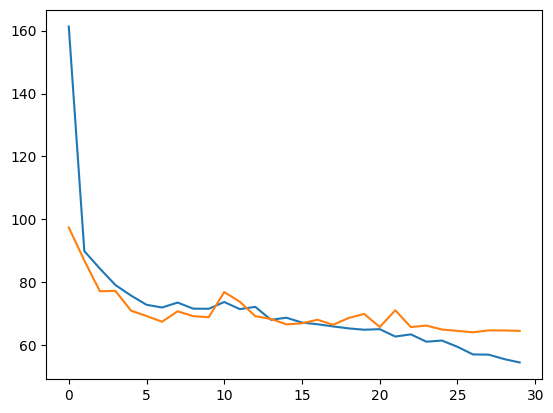

In [17]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

In [18]:
test_image = mpimg.imread('images.jpg')
TARGET_SIZE = 416

In [19]:
test_image = cv2.resize(test_image, (TARGET_SIZE, TARGET_SIZE))
test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2GRAY)
test_image = test_image / 255
test_image = test_image.reshape(1, TARGET_SIZE, TARGET_SIZE, 1)

In [20]:
xmin = int(xmin)
ymin = int(ymin)
xmax = int(xmax)
ymax = int(ymax)

In [21]:
test_image = test_image.reshape(TARGET_SIZE, TARGET_SIZE, 1)
test_image_copy = test_image.copy()
cv2.rectangle(test_image_copy, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)

array([[[0.73333333],
        [0.73333333],
        [0.7372549 ],
        ...,
        [0.80784314],
        [0.80784314],
        [0.80784314]],

       [[0.73333333],
        [0.73333333],
        [0.7372549 ],
        ...,
        [0.80784314],
        [0.80784314],
        [0.80784314]],

       [[0.7372549 ],
        [0.7372549 ],
        [0.7372549 ],
        ...,
        [0.80784314],
        [0.80784314],
        [0.80784314]],

       ...,

       [[0.10588235],
        [0.10980392],
        [0.11372549],
        ...,
        [0.6627451 ],
        [0.6627451 ],
        [0.6627451 ]],

       [[0.10588235],
        [0.10980392],
        [0.11372549],
        ...,
        [0.6627451 ],
        [0.65882353],
        [0.65882353]],

       [[0.10588235],
        [0.10980392],
        [0.11372549],
        ...,
        [0.6627451 ],
        [0.65882353],
        [0.65882353]]], shape=(416, 416, 1))

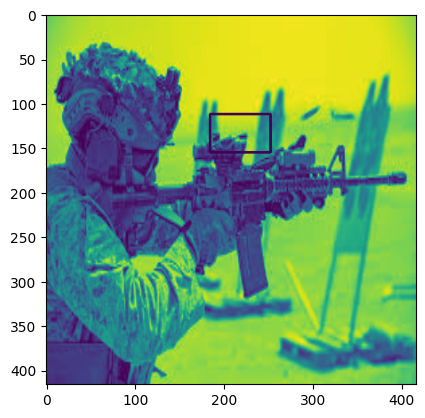

In [22]:
plt.imshow(test_image_copy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


(np.float64(-0.5), np.float64(415.5), np.float64(415.5), np.float64(-0.5))

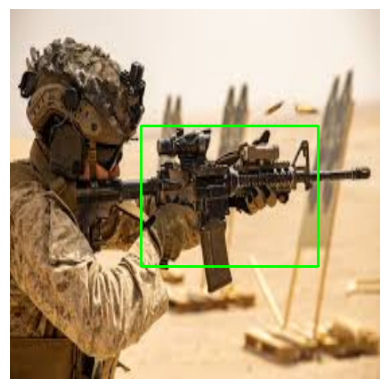

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
TARGET_SIZE = 416
test_image = cv2.imread("images.jpg")
test_image = cv2.resize(test_image, (TARGET_SIZE, TARGET_SIZE))

test_image = test_image.astype("float32") / 255.0

test_input = np.expand_dims(test_image, axis=0)

xmin, ymin, xmax, ymax = model.predict(test_input)[0]

xmin, ymin, xmax, ymax = map(int, [xmin, ymin, xmax, ymax])
img_draw = (test_image * 255).astype("uint8")
cv2.rectangle(img_draw,
              (xmin, ymin),
              (xmax, ymax),
              (0, 255, 0),
              2)
plt.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
plt.axis("off")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


(np.float64(-0.5), np.float64(415.5), np.float64(415.5), np.float64(-0.5))

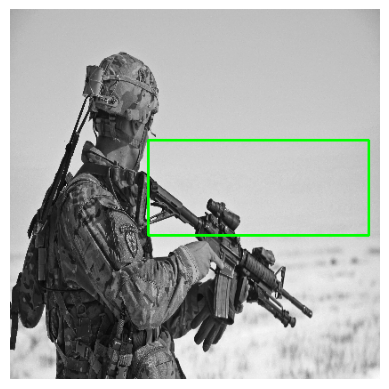

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
TARGET_SIZE = 416
test_image = cv2.imread("image_1.jpg")
test_image = cv2.resize(test_image, (TARGET_SIZE, TARGET_SIZE))

test_image = test_image.astype("float32") / 255.0

test_input = np.expand_dims(test_image, axis=0)

xmin, ymin, xmax, ymax = model.predict(test_input)[0]

xmin, ymin, xmax, ymax = map(int, [xmin, ymin, xmax, ymax])
img_draw = (test_image * 255).astype("uint8")
cv2.rectangle(img_draw,
              (xmin, ymin),
              (xmax, ymax),
              (0, 255, 0),
              2)
plt.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
plt.axis("off")